# High-rate E2E optimization: digital surrogate and trainable TX LUT

This notebook reproduces the October 1, 2026 validated workflow without modifying earlier notebooks or paper deliverables.

1. Fit or load a **hybrid digital surrogate** from simulated input/output sequences.
2. Initialize TX/RX on conventional BPAM; jointly optimize the neural TX and RX through the frozen digital surrogate.
3. Export the neural mapping to a **1024 × 2 voltage LUT**. Keep differential precoding, pulse shaping and DAC outside the table.
4. Continue LUT + RX training. Continue NN + RX for the same additional budget as a control.
5. Test both fixed pairs on the **analytical reference channel**, check sampling convergence and inspect noiseless MZM eyes.

The digital surrogate identifies three FIR responses. MZM, fiber dispersion/loss and ASE laws remain known physics. This is simulator validation, **not laboratory validation**.


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from pathlib import Path
from copy import deepcopy
from datetime import datetime
import hashlib
import json
import sys

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "functions/channel.py").exists())
sys.path.insert(0, str(ROOT / "functions"))
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display
import highrate_workflow as workflow

torch.set_num_threads(2)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
FORCE_RETRAIN = True  # One switch for digital surrogate, BPAM pretraining, joint NN and LUT training.
SEED = 0  # 0 or 1; fixed in advance, not selected using test BER.
OSNR_GRID = list(range(13, 20))
BLOCKS_BY_OSNR = {str(v): (128 if v <= 16 else 256 if v == 17 else 512 if v == 18 else 1024) for v in OSNR_GRID}
print(f"Project: {ROOT}\nDevice: {DEVICE}\nInitialization: {SEED}")


Project: c:\Users\celli\Documents\MLforCPO2
Device: cuda
Initialization: 0


## Sampling rates and physical chain

**20 GBaud, 40 Gb/s.** TX: FC-16, five-symbol context (10 coded bits), two voltage outputs per symbol. RX: one FC-64-128-32 network, 12 input samples, two bit probabilities plus a training-only symbol head.

| Stage | Samples/symbol | Sample rate |
|---|---:|---:|
| TX DSP and 6-bit DAC | 2 | 40 GSa/s |
| Reconstructed drive, MZM, fiber and photodiode | 8 | 160 GSa/s |
| RX sampling and 6-bit ADC | 2 | 40 GSa/s |
| Numerical check / eye rendering | 16 / 32 | 320 / 640 GSa/s |

NRZ (roll-off 0.85) is followed by the ideal 20 GHz frequency rect. FFT reconstruction is **after the DAC**. The receiver uses a 10 GHz Gaussian filter before decimation/ADC, without a BPAM matched filter. MZM ER = 30 dB, C-band fiber = 10.238 km. TX and RX rates do not increase when the analog simulation rate increases.

All training uses constant Adam learning rate 0.001, no scheduler. Joint training uses Eb/N0 = 14 dB (OSNR = 16.05 dB), bit BCE plus auxiliary symbol CE, and **uncoded bits as targets**.


In [2]:
tx, reference, rx, cfg = workflow.build_system(8, seed=SEED, device=DEVICE)
assert tx.tx_subsymbols == 2
assert cfg.samples_per_symbol_sim == 8 and rx.samples_per_symbol_rx == 2
print(f"TX outputs/symbol: {tx.tx_subsymbols}; RX context: {rx.window_size} samples")
print(f"Analog sample rate: {cfg.sim_sample_rate / 1e9:g} GSa/s")
print("TX: NRZ -> ideal frequency rect 20 GHz -> DAC -> reconstruction")

core_files = [ROOT / "functions" / n for n in workflow.VALIDATED_CODE]
core_files.append(Path(workflow.__file__))
fingerprint = hashlib.sha256(json.dumps({
    "recipe": workflow.RECIPE, "seed": SEED,
    "code": {p.name: workflow.file_digest(p) for p in core_files},
    "config": vars(cfg),
}, sort_keys=True).encode()).hexdigest()
base = ROOT / "results/bpam_lut_highrate" / f"seed{SEED}_{fingerprint[:12]}"
base.mkdir(parents=True, exist_ok=True)
latest = base / "current.json"
if FORCE_RETRAIN:
    WORK = base / ("run_" + datetime.now().strftime("%Y%m%d_%H%M%S_%f"))
    run_info = {"folder": WORK.name, "fresh_training": True}
elif latest.exists():
    run_info = json.loads(latest.read_text())
    WORK = base / run_info["folder"]
else:
    WORK = base / "validated_cache"
    run_info = {"folder": WORK.name, "fresh_training": False}
WORK.mkdir(parents=True, exist_ok=True)
workflow.save_json(latest, run_info)
archived = {} if run_info["fresh_training"] else workflow.validated_artifacts(ROOT, SEED)
workflow.save_json(WORK / "recipe.json", {"fingerprint": fingerprint, "recipe": workflow.RECIPE,
    "seed": SEED, "config": vars(cfg), "force_retrain": FORCE_RETRAIN})
print(f"Output directory: {WORK}")
print("Existing validated artifacts are read-only. No historical file will be overwritten.")


TX outputs/symbol: 2; RX context: 12 samples
Analog sample rate: 160 GSa/s
TX: NRZ -> ideal frequency rect 20 GHz -> DAC -> reconstruction
Output directory: c:\Users\celli\Documents\MLforCPO2\results\bpam_lut_highrate\seed0_148c6ac7f9dc\run_20261001_213942_123980
Existing validated artifacts are read-only. No historical file will be overwritten.


## 1. Fit or load the digital surrogate

The three 257-tap FIRs start from identity responses when fitting from scratch. Their coefficients are trained with normalized MSE plus an L2 penalty of 0.001. Excitation: 16 clipped-Gaussian drive blocks; validation: four independent blocks; test: four further blocks. Each block has 8192 analog samples; 1024 samples at each edge are discarded.

The best validation objective selects the fitted model (40k updates). Held-out noiseless, paired-ASE and input-gradient checks must pass before DSP training. Once accepted, channel parameters are **frozen**, but gradients still propagate through the channel to TX.

With `FORCE_RETRAIN=False`, compatible checkpoints are loaded; missing stages are trained. With `True`, every training stage is rerun in a new directory, including conventional BPAM initialization. Interruptions within a stage can be resumed by rerunning with `False`.


In [3]:
digital_surrogate, digital_path, fit_report = workflow.fit_digital_surrogate(
    reference, cfg, WORK / "digital_surrogate",
    historical=archived.get("digital_surrogate"), steps=workflow.RECIPE["fit_steps"])
digital_digest = workflow.file_digest(digital_path)
assert all(not p.requires_grad and p.grad is None for p in digital_surrogate.parameters())
print(f"Digital surrogate: {digital_path}")
display(fit_report)
workflow.save_json(WORK / "digital_surrogate_validation.json", fit_report)


Digital surrogate 1000/40000: validation NMSE=0.216685
Digital surrogate 2000/40000: validation NMSE=0.0594524
Digital surrogate 3000/40000: validation NMSE=0.0235418
Digital surrogate 4000/40000: validation NMSE=0.0115457
Digital surrogate 5000/40000: validation NMSE=0.00451392
Digital surrogate 6000/40000: validation NMSE=0.00245612
Digital surrogate 7000/40000: validation NMSE=0.00162399
Digital surrogate 8000/40000: validation NMSE=0.00101085
Digital surrogate 9000/40000: validation NMSE=0.000716779
Digital surrogate 10000/40000: validation NMSE=0.000572579
Digital surrogate 11000/40000: validation NMSE=0.000337363
Digital surrogate 12000/40000: validation NMSE=0.000292251
Digital surrogate 13000/40000: validation NMSE=0.000244048
Digital surrogate 14000/40000: validation NMSE=0.000266106
Digital surrogate 15000/40000: validation NMSE=0.00012325
Digital surrogate 16000/40000: validation NMSE=4.11114e-05
Digital surrogate 17000/40000: validation NMSE=0.000139246
Digital surrogate 18

{'noiseless_nmse': 2.7348194026987964e-05,
 'paired_ASE_nmse': 0.00012208021772441537,
 'input_gradients': [{'cosine': 0.9999858140945435,
   'relative_l2': 0.0053217289969325066},
  {'cosine': 0.9999874830245972, 'relative_l2': 0.004981245845556259},
  {'cosine': 0.9999873638153076, 'relative_l2': 0.005044448189437389},
  {'cosine': 0.999986469745636, 'relative_l2': 0.005198993720114231}],
 'passed': True}

## 2. Conventional BPAM initialization, then joint NN + RX training

Initialization is standard supervised pretraining, not a constraint on the final modulation:

- Train RX for 100k steps against a fixed conventional BPAM transmitter on the same high-rate analytical chain.
- Train neural TX for 8k steps to reproduce conventional BPAM voltage targets (first output slot: BPAM level; second: zero).
- Jointly optimize TX and RX for 100k steps through the **frozen digital surrogate**.

This initialization has an additional pretraining budget; it is not a random-from-scratch joint experiment. No BPAM target, polarity penalty or constellation regularizer is used during joint training. Both TX and RX weights are updated.


In [4]:
initial_path = archived.get("initial", WORK / "bpam_initial.pt")
if initial_path.exists():
    workflow.load_pair(tx, rx, initial_path)
    print(f"Loaded conventional BPAM initialization: {initial_path}")
else:
    fixed_tx, fixed_reference, fixed_rx, fixed_cfg = workflow.build_system(8, seed=SEED, fixed=True, device=DEVICE)
    workflow.train_pair(fixed_tx, fixed_rx, fixed_reference, fixed_cfg, WORK / "stage1_rx.pt",
        workflow.RECIPE["rx_steps"], 600000 + SEED, mode="rx", upstream={"workflow": fingerprint})
    with torch.no_grad():
        for name, p in rx.named_parameters():
            p.copy_(dict(fixed_rx.named_parameters())[name])
    del fixed_tx, fixed_reference, fixed_rx
    workflow.train_pair(tx, rx, reference, cfg, WORK / "stage2_tx.pt",
        workflow.RECIPE["tx_steps"], 700000 + SEED, mode="tx", upstream={"workflow": fingerprint})
    workflow.save_checkpoint(initial_path, {"tx": tx.state_dict(), "rx": rx.state_dict()})

joint_path = workflow.train_pair(tx, rx, digital_surrogate, cfg, WORK / "joint_nn.pt",
    workflow.RECIPE["joint_steps"], 202610010 + SEED,
    upstream={"initial_sha256": workflow.file_digest(initial_path), "digital_sha256": digital_digest},
    historical=archived.get("joint"))
print(f"Joint NN + RX: {joint_path}")


{'mode': 'rx', 'step': 1, 'loss': 2.084240674972534}
{'mode': 'rx', 'step': 1000, 'loss': 0.024195970967411995}
{'mode': 'rx', 'step': 2000, 'loss': 0.021143807098269463}
{'mode': 'rx', 'step': 3000, 'loss': 0.01863137260079384}
{'mode': 'rx', 'step': 4000, 'loss': 0.01471242681145668}
{'mode': 'rx', 'step': 5000, 'loss': 0.020038845017552376}
{'mode': 'rx', 'step': 6000, 'loss': 0.018686262890696526}
{'mode': 'rx', 'step': 7000, 'loss': 0.021154135465621948}
{'mode': 'rx', 'step': 8000, 'loss': 0.01992199756205082}
{'mode': 'rx', 'step': 9000, 'loss': 0.012285959906876087}
{'mode': 'rx', 'step': 10000, 'loss': 0.015786997973918915}
{'mode': 'rx', 'step': 11000, 'loss': 0.018701113760471344}
{'mode': 'rx', 'step': 12000, 'loss': 0.012205621227622032}
{'mode': 'rx', 'step': 13000, 'loss': 0.016862090677022934}
{'mode': 'rx', 'step': 14000, 'loss': 0.015257952734827995}
{'mode': 'rx', 'step': 15000, 'loss': 0.012241254560649395}
{'mode': 'rx', 'step': 16000, 'loss': 0.011789103969931602}

## 3. Exhaustive export to a voltage LUT

A five-symbol, two-bit context has **1024 rows**. The table returns two pre-filter voltage samples per row. Bit ordering is stream-major and MSB-first; differential encoding is the same external cumulative XOR as in the neural transmitter.

The LUT stores trainable floating-point voltages; the unchanged DAC quantizes the filtered drive to six bits. This does not imply that table entries themselves are stored in six-bit fixed point.

Check all local contexts plus random, constant and alternating sequences before training the table. Export preserves the initial mapping up to floating-point rounding; finetuning can then change it.


In [5]:
source_tx, source_rx = deepcopy(tx).eval(), deepcopy(rx).eval()
lut = workflow.export_coded_lut(source_tx)
export_report = workflow.audit_export(source_tx, lut)
display(export_report)
workflow.save_json(WORK / "lut_export_validation.json", export_report)

nn_control, nn_rx = deepcopy(source_tx), deepcopy(source_rx)
lut_rx = deepcopy(source_rx)
print(f"LUT shape: {tuple(lut.embedding.weight.shape)}; trainable entries: {lut.embedding.weight.numel()}")


{'rows': 1024,
 'samples_per_row': 2,
 'exhaustive_max_error_V': 0.0,
 'checks': [{'pre_DAC_max_error_V': 1.9073486328125e-06,
   'post_DAC_max_error_V': 0.0},
  {'pre_DAC_max_error_V': 0.0, 'post_DAC_max_error_V': 0.0},
  {'pre_DAC_max_error_V': 4.76837158203125e-07, 'post_DAC_max_error_V': 0.0},
  {'pre_DAC_max_error_V': 9.5367431640625e-07, 'post_DAC_max_error_V': 0.0}],
 'precoder': 'External cumulative XOR, unchanged'}

LUT shape: (1024, 2); trainable entries: 2048


## 4. Matched 20k-step continuation

NN + RX and LUT + RX start from the same 100k-step pair, with fresh Adam optimizers. Both see the same training bit/ASE seeds and receive 20k additional updates, serially on the GPU. LUT voltages are projected onto the original drive interval after each update. The digital surrogate remains frozen.

The continued NN is the fair control: comparing only against the pre-export 100k-step NN would confound LUT training with the extra training budget.


In [6]:
upstream = {"joint_sha256": workflow.file_digest(joint_path), "digital_sha256": digital_digest}
nn_path = workflow.train_pair(nn_control, nn_rx, digital_surrogate, cfg, WORK / "continued_nn.pt",
    workflow.RECIPE["continuation_steps"], 202610012 + SEED, upstream=upstream, historical=archived.get("nn"))
lut_path = workflow.train_pair(lut, lut_rx, digital_surrogate, cfg, WORK / "trained_lut.pt",
    workflow.RECIPE["continuation_steps"], 202610012 + SEED, upstream=upstream, historical=archived.get("lut"))
pairs = {"nn": (nn_control.eval(), nn_rx.eval()), "lut": (lut.eval(), lut_rx.eval())}
pair_hashes = {"nn": workflow.file_digest(nn_path), "lut": workflow.file_digest(lut_path)}
workflow.save_json(WORK / "artifacts.json", {"digital_surrogate": str(digital_path),
    "initial": str(initial_path), "joint_nn": str(joint_path),
    "continued_nn": str(nn_path), "trained_lut": str(lut_path), "sha256": pair_hashes})


{'mode': 'joint', 'step': 1, 'loss': 0.0016499970806762576}
{'mode': 'joint', 'step': 1000, 'loss': 0.002626762492582202}
{'mode': 'joint', 'step': 2000, 'loss': 0.0017715163994580507}
{'mode': 'joint', 'step': 3000, 'loss': 0.0011188199277967215}
{'mode': 'joint', 'step': 4000, 'loss': 0.004050609190016985}
{'mode': 'joint', 'step': 5000, 'loss': 0.0034853308461606503}
{'mode': 'joint', 'step': 6000, 'loss': 0.005138586740940809}
{'mode': 'joint', 'step': 7000, 'loss': 0.0033975415863096714}
{'mode': 'joint', 'step': 8000, 'loss': 0.006028681993484497}
{'mode': 'joint', 'step': 9000, 'loss': 0.0023526528384536505}
{'mode': 'joint', 'step': 10000, 'loss': 0.0023975607473403215}
{'mode': 'joint', 'step': 11000, 'loss': 0.003076133318245411}
{'mode': 'joint', 'step': 12000, 'loss': 0.0030931374058127403}
{'mode': 'joint', 'step': 13000, 'loss': 0.003970646299421787}
{'mode': 'joint', 'step': 14000, 'loss': 0.002031230367720127}
{'mode': 'joint', 'step': 15000, 'loss': 0.00443404540419578

## 5. Numerical sampling check and held-out BER

Testing uses the analytical channel, not the fitted model. Guarded, noiseless RX windows at 8 and 16 sps must agree (NMSE ≤ 0.0001).

The OSNR grid is 13–19 dB. The predeclared evaluation budget is 128 blocks per point up to 16 dB, then 256/512/1024 blocks at 17/18/19 dB; each block has 32768 symbols with 128 edge symbols discarded on each side. The two pairs use identical new test bits and ASE seeds. At least 200 errors are recommended for precise comparisons; low-error points are flagged, and zero-error measurements are not plotted as BER = 0.

If the exact deployed checkpoint hashes and evaluation budgets match the completed full-grid validation, its counts are loaded rather than repeating the test. Otherwise the notebook evaluates and saves resumable counts. No test-based parameter selection is performed.


In [7]:
sampling = {name: workflow.sampling_check(t, r, reference, cfg) for name, (t, r) in pairs.items()}
display(sampling)
assert all(row["passed"] for row in sampling.values()), "Sampling check failed; inspect before reporting BER."
workflow.save_json(WORK / "sampling_validation.json", sampling)

fullgrid = ROOT / "results/sim_surrogate/20261001_lut_fullgrid"
points = None
if (fullgrid / "summary.json").exists():
    summary = json.loads((fullgrid / "summary.json").read_text())
    protocol = summary["protocol"]
    known = protocol["artifacts"][f"seed{SEED}"]
    if (all(pair_hashes[a] == known[a]["sha256"] for a in pairs)
            and all(protocol["blocks_by_OSNR"].get(k) == v for k, v in BLOCKS_BY_OSNR.items())):
        points = {str(v): {"models": {a: summary["points"][str(v)]["models"][f"seed{SEED}_{a}"] for a in pairs}}
                  for v in OSNR_GRID}
        print(f"Loaded matching held-out counts: {fullgrid / 'summary.json'}")
if points is None:
    points = workflow.evaluate_pairs(pairs, reference, cfg, BLOCKS_BY_OSNR,
                                    WORK / "evaluation_counts.json", pair_hashes)
workflow.save_json(WORK / "evaluation_summary.json", {"points": points, "checkpoint_sha256": pair_hashes,
    "test_channel": "Analytical reference, 8 sps", "sampling": sampling})


{'nn': {'rx_window_nmse_8_16': 1.2073016478097998e-05, 'passed': True},
 'lut': {'rx_window_nmse_8_16': 2.4785576897556894e-05, 'passed': True}}

OSNR 13: nn=0.00869294 (72352 errors), lut=0.00822136 (68427 errors)
OSNR 14: nn=0.00373564 (31092 errors), lut=0.00343479 (28588 errors)
OSNR 15: nn=0.00134794 (11219 errors), lut=0.00116592 (9704 errors)
OSNR 16: nn=0.000396488 (3300 errors), lut=0.000332449 (2767 errors)
OSNR 17: nn=9.97829e-05 (1661 errors), lut=6.84243e-05 (1139 errors)
OSNR 18: nn=1.98544e-05 (661 errors), lut=1.26155e-05 (420 errors)
OSNR 19: nn=2.67329e-06 (178 errors), lut=1.45679e-06 (97 errors)


OSNR=13 NN : BER=0.008692944, errors=72352, bits=8323072
OSNR=14 NN : BER=0.00373564, errors=31092, bits=8323072
OSNR=15 NN : BER=0.00134794, errors=11219, bits=8323072
OSNR=16 NN : BER=0.0003964882, errors=3300, bits=8323072
OSNR=17 NN : BER=9.978287e-05, errors=1661, bits=16646144
OSNR=18 NN : BER=1.985445e-05, errors=661, bits=33292288
OSNR=19 NN : BER=2.673292e-06, errors=178, bits=66584576 [fewer than 200 errors]
OSNR=13 LUT: BER=0.008221363, errors=68427, bits=8323072
OSNR=14 LUT: BER=0.003434789, errors=28588, bits=8323072
OSNR=15 LUT: BER=0.001165916, errors=9704, bits=8323072
OSNR=16 LUT: BER=0.0003324494, errors=2767, bits=8323072
OSNR=17 LUT: BER=6.842425e-05, errors=1139, bits=16646144
OSNR=18 LUT: BER=1.261553e-05, errors=420, bits=33292288
OSNR=19 LUT: BER=1.456794e-06, errors=97, bits=66584576 [fewer than 200 errors]


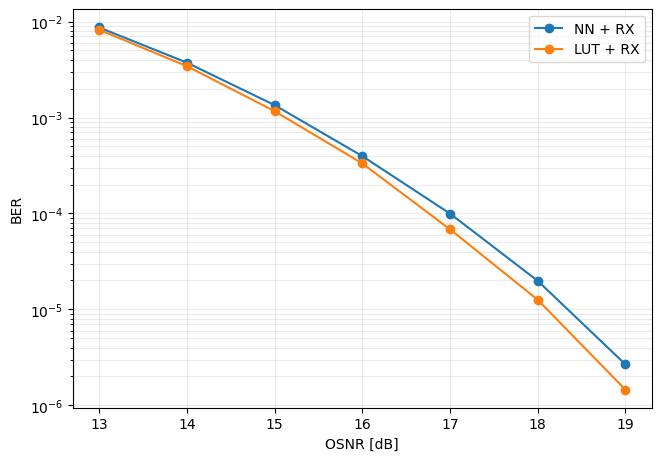

In [8]:
table = np.array([[v] + [points[str(v)]["models"][a]["ber"] for a in pairs] for v in OSNR_GRID])
np.savetxt(WORK / "bpam_lut_highrate.txt", table, fmt="%.9e", header=
    "Frozen digital surrogate during training; analytical channel for BER. ADC/DAC 6 bits.\n"
    "Matched 20k-step continuation after 100k joint steps and conventional BPAM pretraining.\n"
    "Columns: OSNR_dB NN_RX_BER LUT_RX_BER\nCounts: evaluation_summary.json")
fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)
for i, name in enumerate(pairs, 1):
    values = np.where(table[:, i] > 0, table[:, i], np.nan)
    ax.semilogy(table[:, 0], values, "-o", label=name.upper() + " + RX")
    for v in OSNR_GRID:
        row = points[str(v)]["models"][name]
        print(f"OSNR={v:2d} {name.upper():3s}: BER={row['ber']:.7g}, errors={row['errors']}, bits={row['bits']}"
              + (" [fewer than 200 errors]" if row["errors"] < 200 else ""))
ax.set(xlabel="OSNR [dB]", ylabel="BER", xticks=OSNR_GRID)
ax.grid(True, which="both", alpha=.25)
ax.legend()
fig.savefig(WORK / "bpam_lut_highrate.png", dpi=180)
plt.show()


## 6. Noiseless pre/post-MZM eyes

Same bit sequence and folding phase, native 32-sps analog simulation, 5000 traces. Rows: standard BPAM, continued NN and trained LUT. Drive is shown as V/Vπ; optical field and power are not rescaled. These signals precede fiber and ASE. BPAM uses Vpeak = 0.6 Vπ as an eye reference; NN/LUT retain their original allowed drive range.

Context-dependent deterministic traces are not optical noise. Eye appearance or polarity statistics alone do not identify a modulation format. The BPAM row is an illustration, not a BER baseline for this comparison.


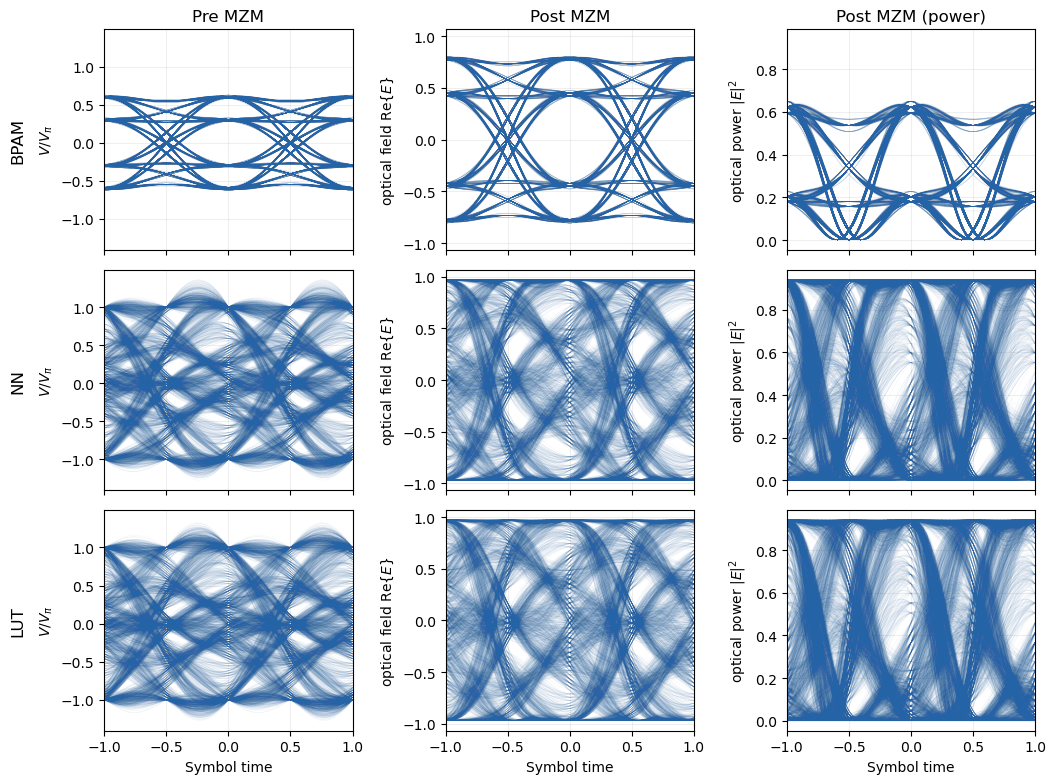

BER data: c:\Users\celli\Documents\MLforCPO2\results\bpam_lut_highrate\seed0_148c6ac7f9dc\run_20261001_213942_123980\bpam_lut_highrate.txt
MZM eyes: c:\Users\celli\Documents\MLforCPO2\results\bpam_lut_highrate\seed0_148c6ac7f9dc\run_20261001_213942_123980\mzm_comparison.png


In [9]:
eye_figure = workflow.plot_mzm_eyes(pairs, WORK)
plt.show()
workflow.save_json(WORK / "complete.json", {"fingerprint": fingerprint,
    "artifacts": {"nn": str(nn_path), "lut": str(lut_path), "digital_surrogate": str(digital_path)},
    "checkpoint_sha256": pair_hashes, "digital_surrogate_sha256": digital_digest,
    "sampling": sampling, "scope": "Selected fixed initialization; simulator validation, not laboratory results"})
print(f"BER data: {WORK / 'bpam_lut_highrate.txt'}")
print(f"MZM eyes: {WORK / 'mzm_comparison.png'}")
